In [1]:
# Import necessary libraries
import pytz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.dates as mdates
from scipy import stats
from sklearn.decomposition import PCA
from scipy.signal import detrend
from sklearn.preprocessing import StandardScaler
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap
from astral import LocationInfo
from astral.sun import sun
from datetime import datetime, date
from jiflr import ROOT

In [2]:
# Function to calculate lapse rate
def calculate_lapse_rate(temps, elevations):
    """Calculate temperature lapse rate in °C/100m"""
    # Use only non-NaN pairs of temperature and elevation
    valid_mask = ~np.isnan(temps) & ~np.isnan(elevations)
    if sum(valid_mask) < 2:  # Need at least 2 points for regression
        return np.nan, np.nan, np.nan

    # Linear regression: temp ~ elevation
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        elevations[valid_mask], temps[valid_mask]
    )

    # Convert slope to °C/100m
    lapse_rate = slope * 100

    return lapse_rate, r_value**2, p_value


def get_season(date):
    """Determine season from date"""
    month = date.month
    
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Fall'
    else:
        return 'Winter'
    

def calculate_temporal_lapse_rates(df, period='monthly', station_filter=None):
    """
    Calculate lapse rates with temporal aggregation and optional station filtering
    
    Parameters:
    -----------
    df : pandas DataFrame
        Weather data with temperature, elevation, year, month, camp_id columns
    period : str
        Aggregation period: 'daily' or 'monthly'
    station_filter : function, optional
        A function that takes a dataframe and returns a filtered dataframe
        e.g., lambda df: df[df['maritime']]
    
    Returns:
    --------
    pandas.DataFrame with lapse rates
    """
    # Create a dataframe to store lapse rates
    lapse_rates = []
    
    # Apply station filter if provided
    if station_filter is not None:
        df = station_filter(df)
    
    # Group by appropriate time period and sun_up status
    if period == 'daily':
        # Use year, month, day for daily calculations
        groupby_cols = ['year', 'month', 'day', 'sun_up']
    else:  # monthly
        # Use year, month for monthly calculations
        groupby_cols = ['year', 'month', 'sun_up']
    
    for group_key, group in df.groupby(groupby_cols):
        # Extract group information
        if period == 'daily':
            year, month, day, sun_up = group_key
        else:  # monthly
            year, month, sun_up = group_key
            day = 1  # Default day for monthly aggregation
        
        # Group by station and calculate average temperature
        station_temps = group.groupby(['camp_id', 'elevation'])["temperature"].mean().reset_index()
        
        # Only calculate lapse rate if we have enough stations with elevation data
        valid_stations = station_temps.dropna(subset=['elevation'])
        if len(valid_stations) >= 2:
            # Calculate lapse rate
            lr, r2, p = calculate_lapse_rate(
                valid_stations["temperature"].values,
                valid_stations['elevation'].values
            )
            
            # Store results
            result = {
                'year': year,
                'month': month,
                'sun_up': sun_up,
                'lapse_rate': lr,
                'r2': r2,
                'p_value': p,
                'stations_used': len(valid_stations)
            }
            
            # Add day for daily calculations
            if period == 'daily':
                result['day'] = day
                
            lapse_rates.append(result)
    
    # Create dataframe and add date column
    result_df = pd.DataFrame(lapse_rates)
    if not result_df.empty:
        if period == 'daily':
            result_df['date'] = pd.to_datetime(result_df[['year', 'month', 'day']])
        else:  # monthly
            result_df['date'] = pd.to_datetime(result_df[['year', 'month']].assign(day=1))
        
        # Add season column
        result_df['season'] = result_df['date'].apply(get_season)
    
    return result_df


def calculate_sunrise_sunset(latitude, longitude, dates, timezone="America/Anchorage"):
    """
    Calculate sunrise and sunset times for a specific location across multiple dates.

    Parameters:
    latitude (float): Latitude of the location
    longitude (float): Longitude of the location
    dates (iterable): Iterable of dates (datetime, date objects, or pandas Timestamps)
    timezone (str): Timezone string (default: "America/Anchorage")

    Returns:
    tuple: (sunrise_times, sunset_times) - Two arrays of datetime objects
    """
    # Create location
    location = LocationInfo(latitude=latitude, longitude=longitude, timezone=timezone)
    tz = pytz.timezone(timezone)

    # Initialize lists for results
    sunrise_times = []
    sunset_times = []

    # Extract unique dates (in case there are duplicates in the input)
    unique_dates = set()
    for d in dates:
        # Handle different date formats
        if isinstance(d, (pd.Timestamp, datetime)):
            unique_dates.add(d.date())
        elif isinstance(d, date):
            unique_dates.add(d)
        else:
            try:
                # Try to parse string dates
                parsed_date = pd.to_datetime(d).date()
                unique_dates.add(parsed_date)
            except:
                raise ValueError(f"Unrecognized date format: {d}")

    # Sort dates for consistent ordering
    unique_dates = sorted(unique_dates)

    # Calculate sunrise and sunset for each date
    for current_date in unique_dates:
        try:
            s = sun(location.observer, date=current_date, tzinfo=tz)
            sunrise_times.append(s["sunrise"])
            sunset_times.append(s["sunset"])
        except Exception as e:
            # Handle edge cases (e.g., polar day/night)
            print(
                f"Warning: Could not calculate sun times for {current_date} at {latitude},{longitude}: {e}"
            )
            sunrise_times.append(None)
            sunset_times.append(None)

    return sunrise_times, sunset_times

In [12]:
# Utility function for standard formatting
def apply_standard_formatting(ax, set_lims=False):
    """Apply standardized formatting to any plot axis"""
    if set_lims:
        # Set standard y-axis limits
        ax.set_ylim(-2.5, 1.0)
    # Add gridlines
    ax.grid(True, alpha=0.3)
    return ax

In [4]:
# Read the station locations
wx_stations = pd.read_csv(
    Path(
        ROOT,
        "data/external/JIRP_AWS_Stations/juneauIceField_weather_v1.0/WeatherStationLocations.csv",
    )
)
wx_stations

,Location,Elevation,Latitude,Longitude,NWIS ID
0,C-10,1196,59.575640,-133.709820,NaN
1,C-17,1285,58.647210,-134.206350,NaN
2,C-26,1435,58.367370,-134.366380,NaN
3,C-9,1555,59.016640,-134.121040,NaN
4,C-29,1618,58.712433,-134.182217,NaN
5,C-18,1705,59.342110,-134.102210,NaN
6,C-8,2050,58.834970,-134.276430,NaN
7,C-25,2121,58.806700,-134.136130,NaN


In [5]:
# Load the McGee JIRP hourly data
mcgee_data_path = Path(
    ROOT,
    "notebooks/camp-wx-lapse-rate/processed_data/mcgee_jirp_hourly_weather_data.csv",
)
df_mcgee = pd.read_csv(mcgee_data_path)

# Convert to datetime and sort
df_mcgee["datetime"] = pd.to_datetime(df_mcgee["datetime"], format="mixed").dt.round(
    "s"
)
df_mcgee = df_mcgee.sort_values(["camp_id", "datetime"])

# Approach: Handle the DST transitions manually, not relying on automatic handling

# 1. Make a copy of the original naive datetimes for reference
df_mcgee["naive_dt"] = df_mcgee["datetime"].copy()


# 2. Use a function to manually handle each timestamp
def localize_with_dst_handling(dt, is_dup):
    ak_tz = pytz.timezone("America/Anchorage")

    try:
        # For spring transition (nonexistent times)
        return dt.tz_localize(ak_tz, nonexistent="shift_backward")
    except pytz.exceptions.AmbiguousTimeError:
        # For fall transition (ambiguous times)
        # First occurrence is DST, second is standard time
        return dt.tz_localize(ak_tz, ambiguous=not is_dup)
    except Exception as e:
        print(f"Error with {dt}: {e}")
        return pd.NaT


# 3. Apply the function row by row
# First, identify duplicates for the fall transition
df_mcgee["is_duplicate"] = df_mcgee.duplicated(["datetime", "camp_id"], keep="first")

# Apply localization with proper handling
result = []
for idx, row in df_mcgee.iterrows():
    localized_dt = localize_with_dst_handling(row["datetime"], row["is_duplicate"])
    result.append(localized_dt)

df_mcgee["datetime"] = result

# 4. Clean up and sort
df_mcgee["date"] = df_mcgee["datetime"].dt.date
df_mcgee = df_mcgee.drop(["is_duplicate"], axis=1)
df_mcgee = df_mcgee.sort_values(["camp_id", "datetime"])
df_mcgee

,datetime,camp_id,temperature,elevation,latitude,longitude,nwis_id,date,naive_dt
367,1998-08-02 07:00:00-08:00,C-10,46.820,1196,59.57564,-133.70982,NaN,1998-08-02,1998-08-02 07:00:00
373,1998-08-02 10:00:00-08:00,C-10,62.170,1196,59.57564,-133.70982,NaN,1998-08-02,1998-08-02 10:00:00
378,1998-08-02 13:00:00-08:00,C-10,55.280,1196,59.57564,-133.70982,NaN,1998-08-02,1998-08-02 13:00:00
384,1998-08-02 16:00:00-08:00,C-10,59.420,1196,59.57564,-133.70982,NaN,1998-08-02,1998-08-02 16:00:00
390,1998-08-02 19:00:00-08:00,C-10,59.420,1196,59.57564,-133.70982,NaN,1998-08-02,1998-08-02 19:00:00
...,...,...,...,...,...,...,...,...,...
1285861,2024-07-24 07:00:00-08:00,C-8,45.172,2050,58.83497,-134.27643,NaN,2024-07-24,2024-07-24 07:00:00
1285866,2024-07-24 08:00:00-08:00,C-8,45.444,2050,58.83497,-134.27643,NaN,2024-07-24,2024-07-24 08:00:00
1285871,2024-07-24 09:00:00-08:00,C-8,45.624,2050,58.83497,-134.27643,NaN,2024-07-24,2024-07-24 09:00:00
1285876,2024-07-24 10:00:00-08:00,C-8,46.841,2050,58.83497,-134.27643,NaN,2024-07-24,2024-07-24 10:00:00


In [6]:
# ======================
# VERIFICATION CHECKS
# ======================

# 1. Check for duplicates in processed data
duplicate_check = df_mcgee.duplicated(["datetime", "camp_id"], keep=False)
if duplicate_check.any():
    print("WARNING: Duplicates found after processing!")
    print(f"Number of duplicates: {duplicate_check.sum()}")
    duplicates = df_mcgee[duplicate_check].sort_values(["camp_id", "datetime"])
    print(duplicates[["camp_id", "datetime", "naive_dt"]].head(10))
else:
    print("SUCCESS: No duplicates found after processing.")

# 2. Check for NaT values
nat_check = df_mcgee["datetime"].isna()
if nat_check.any():
    print(f"WARNING: {nat_check.sum()} NaT values found!")
    print(df_mcgee[nat_check][["camp_id", "naive_dt"]].head())
else:
    print("SUCCESS: No NaT values found.")

# 3. Check for time gaps
df_mcgee = df_mcgee.sort_values(["camp_id", "datetime"])
df_mcgee["time_diff"] = df_mcgee.groupby("camp_id")["datetime"].diff()

# Expected gaps: Mostly 1 hour, some 2 hours for spring transition
one_hour = pd.Timedelta(hours=1)
two_hours = pd.Timedelta(hours=2)

unexpected_gaps = ~(
    (df_mcgee["time_diff"].isna())  # First entry in each group
    | (df_mcgee["time_diff"] == one_hour)  # Normal 1-hour gap
    | (df_mcgee["time_diff"] == two_hours)  # Spring transition 2-hour gap
)

if unexpected_gaps.any():
    print(f"WARNING: {unexpected_gaps.sum()} unexpected time gaps found!")
    print(
        df_mcgee[unexpected_gaps][
            ["camp_id", "datetime", "naive_dt", "time_diff"]
        ].head(10)
    )
else:
    print(
        "SUCCESS: All time gaps are as expected (1 hour or 2 hours for spring transition)."
    )

# Clean up temporary columns
df_mcgee = df_mcgee.drop(["naive_dt", "time_diff"], axis=1)

SUCCESS: No duplicates found after processing.
SUCCESS: No NaT values found.
    camp_id                  datetime            naive_dt       time_diff
373    C-10 1998-08-02 10:00:00-08:00 1998-08-02 10:00:00 0 days 03:00:00
378    C-10 1998-08-02 13:00:00-08:00 1998-08-02 13:00:00 0 days 03:00:00
384    C-10 1998-08-02 16:00:00-08:00 1998-08-02 16:00:00 0 days 03:00:00
390    C-10 1998-08-02 19:00:00-08:00 1998-08-02 19:00:00 0 days 03:00:00
396    C-10 1998-08-02 22:00:00-08:00 1998-08-02 22:00:00 0 days 03:00:00
402    C-10 1998-08-03 01:00:00-08:00 1998-08-03 01:00:00 0 days 03:00:00
408    C-10 1998-08-03 04:00:00-08:00 1998-08-03 04:00:00 0 days 03:00:00
414    C-10 1998-08-03 07:00:00-08:00 1998-08-03 07:00:00 0 days 03:00:00
420    C-10 1998-08-03 10:00:00-08:00 1998-08-03 10:00:00 0 days 03:00:00
426    C-10 1998-08-03 13:00:00-08:00 1998-08-03 13:00:00 0 days 03:00:00


In [ ]:
# Extract time components
df_mcgee["month"] = df_mcgee["datetime"].dt.month
df_mcgee["hour"] = df_mcgee["datetime"].dt.hour
df_mcgee["year"] = df_mcgee["datetime"].dt.year
df_mcgee["day"] = df_mcgee["datetime"].dt.day
df_mcgee["season"] = pd.cut(
    df_mcgee["month"],
    bins=[0, 3, 6, 9, 12],
    labels=["Winter", "Spring", "Summer", "Fall"],
)

# Filter for summer months (June, July, August)
df_mcgee['jja'] = (df_mcgee["month"] >= 6) & (df_mcgee["month"] <= 8)
df_mcgee['mjjas'] = (df_mcgee["month"] >= 5) & (df_mcgee["month"] <= 9)

# Define the transect order from maritime to continental
transect_order = ["C-17", "C-10", "C-9", "C-18", "C-8", "C-25", "C-26", "C-29", "C-30"]
mcgee_transect_order =  ["C-17", "C-10", "C-18", "C-8", "C-25", "C-26"]

# Create a numeric index for the position in the transect
transect_position = {camp: i for i, camp in enumerate(transect_order)}

# Add transect position to the dataframes
df_mcgee["transect_pos"] = df_mcgee["camp_id"].map(transect_position)

# Split stations into maritime and continental segments
maritime_stations = ["C-17", "C-10", "C-9", "C-18", "C-8"]
continental_stations = ["C-8", "C-25", "C-26", "C-29", "C-30"]
icefield_stations = ["C-17", "C-10", "C-9", "C-18","C-8", "C-25", "C-26"]

# Add maritime column (True for camp_id in [17, 10, 9, 18, 8])
df_mcgee['maritime'] = df_mcgee['camp_id'].isin(maritime_stations)

# Add continental column (True for camp_id in [18, 8, 25, 26, 29, 30])
df_mcgee['continental'] = df_mcgee['camp_id'].isin(continental_stations)

# Add on_icefield column (True for all camp_id except 29 and 30)
df_mcgee['on_icefield'] = df_mcgee['camp_id'].isin(icefield_stations)

# Verify the new columns
print(f"Maritime stations: {df_mcgee['maritime'].sum()} rows")
print(f"Continental stations: {df_mcgee['continental'].sum()} rows")
print(f"On icefield stations: {df_mcgee['on_icefield'].sum()} rows")

# Show the distribution by camp_id
summary = df_mcgee.groupby('camp_id').first()[['maritime', 'continental', 'on_icefield']]
print("\nStation classifications:")
print(summary)

# Display basic information about the dataset
print(f"Total records: {len(df_mcgee)}")
print(f"Summer records: {len(df_mcgee_summer)}")
print(f"Date range: {df_mcgee['datetime'].min()} to {df_mcgee['datetime'].max()}")
print(f"Unique stations: {df_mcgee['camp_id'].nunique()}")
print(f"Stations: {sorted(df_mcgee['camp_id'].unique())}")

# Check if we have elevation data for all stations
elevation_summary = df_mcgee.groupby("camp_id")["elevation"].first().reset_index()
print("\nElevation data by station:")
print(elevation_summary)

Maritime stations: 735790 rows
Continental stations: 747585 rows
On icefield stations: 1115075 rows

Station classifications:
         maritime  continental  on_icefield
camp_id                                    
C-10         True        False         True
C-17         True        False         True
C-18         True        False         True
C-25        False         True         True
C-26        False         True         True
C-30        False         True        False
C-8          True         True         True
Total records: 1286726
Summer records: 318436
Date range: 1998-07-20 10:00:00-08:00 to 2024-08-09 15:00:00-08:00
Unique stations: 7
Stations: ['C-10', 'C-17', 'C-18', 'C-25', 'C-26', 'C-30', 'C-8']

Elevation data by station:
  camp_id  elevation
0    C-10       1196
1    C-17       1285
2    C-18       1705
3    C-25       2121
4    C-26       1435
5    C-30        674
6     C-8       2050


In [8]:
# Process each station
for _, station in wx_stations.iterrows():
    station_name = station["Location"]
    lat = float(station["Latitude"])
    lon = float(station["Longitude"])

    # Get data for this station
    station_data = df_mcgee[df_mcgee["camp_id"] == station_name]
    if station_data.empty:
        continue

    # Get unique dates for this station
    dates = station_data["datetime"].unique()

    # Calculate sunrise and sunset times
    sunrise_times, sunset_times = calculate_sunrise_sunset(lat, lon, dates)

    # Create a mapping of date to sunrise/sunset
    sun_dict = {}
    for d, rise, set_ in zip(
        sorted(set(d.date() for d in dates)), sunrise_times, sunset_times
    ):
        sun_dict[d] = (rise, set_)

    # Update the sun_status for each timestamp
    for idx in station_data.index:
        timestamp = df_mcgee.loc[idx, "datetime"]
        day = df_mcgee.loc[idx, "date"]

        if day in sun_dict:
            sunrise, sunset = sun_dict[day]
            if sunrise and sunset and sunrise <= timestamp <= sunset:
                df_mcgee.loc[idx, "sun_up"] = True

# fill the other times with False
df_mcgee["sun_up"] = df_mcgee["sun_up"].fillna(False)

/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_39864/3262265779.py:36: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_mcgee["sun_up"] = df_mcgee["sun_up"].fillna(False)


# Make some plots

## Camp summer temp range

<Axes: xlabel='temperature', ylabel='elevation'>

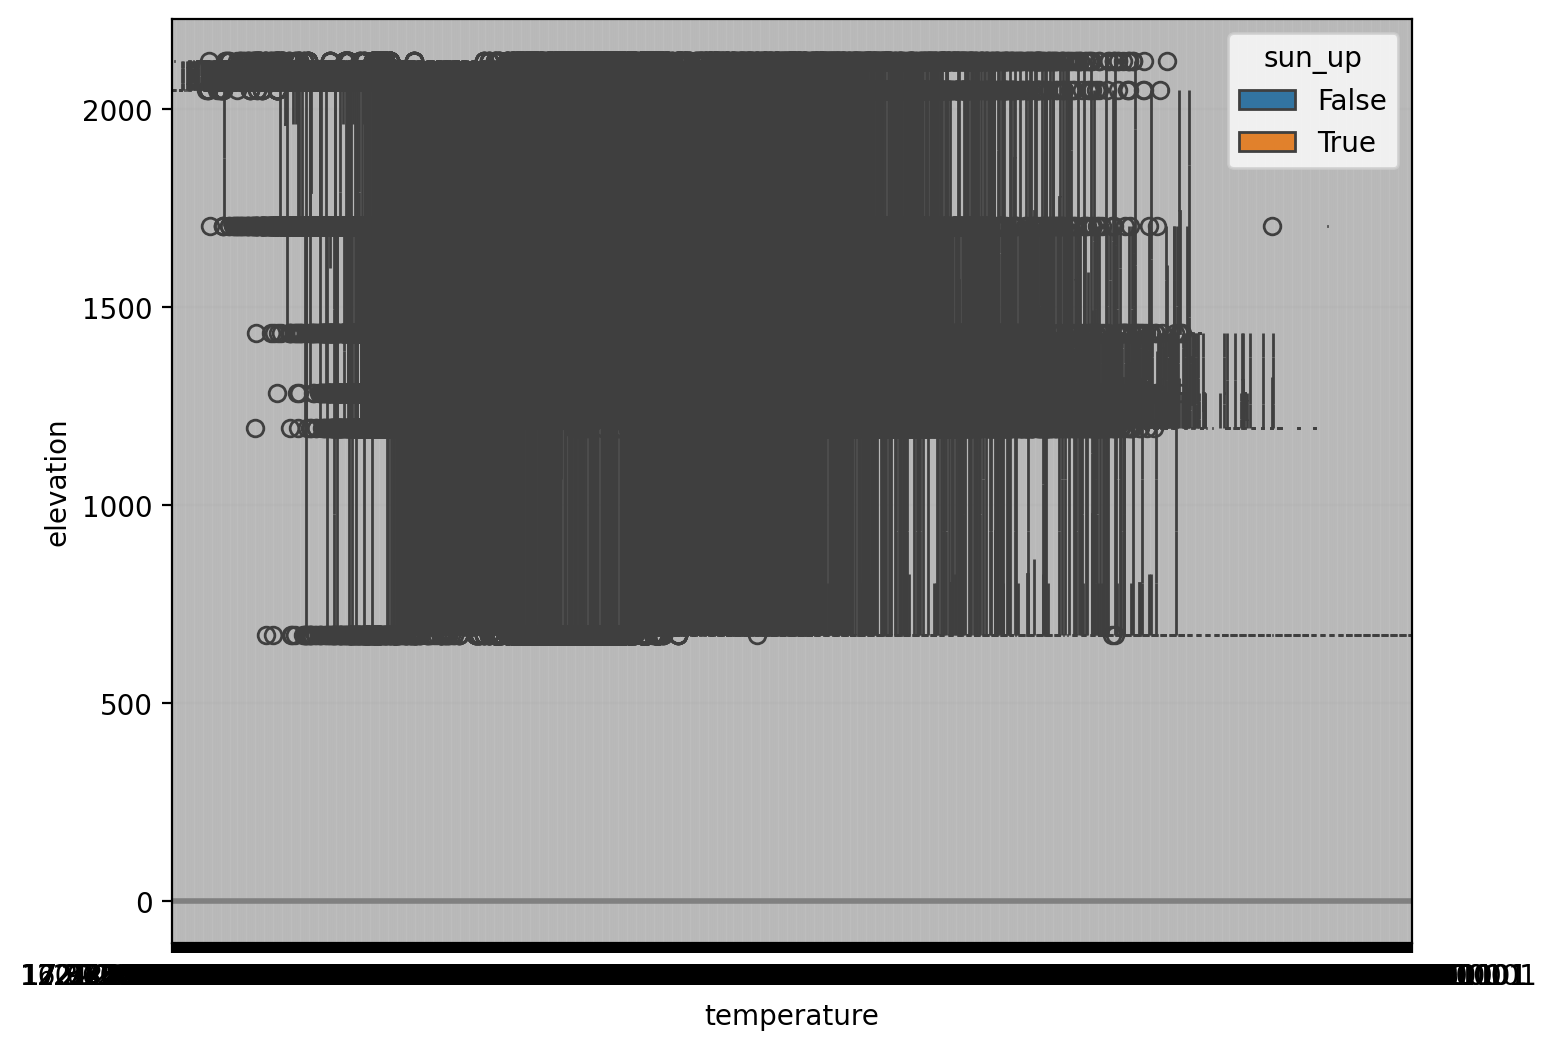

In [36]:
figsize = (8, 6)
dpi = 200
df = df_mcgee.loc[(df_mcgee["jja"])]

# Create the figure
fig, ax = plt.subplots(figsize=figsize, dpi=200)

ax.axhline(0, lw=2, c='grey')

# Create the boxplot using seaborn
sns.boxplot(
    x='temperature',
    y='elevation',
    hue='sun_up',
    #order=mcgee_transect_order,
    data=df,
    #palette={True: 'orangered', False: 'purple'},
    width=0.8,
    orient="x",
    ax=ax
)


apply_standard_formatting(ax)

In [ ]:
figsize = (8, 6)
dpi = 200
df = df_mcgee.loc[(df_mcgee["jja"])]

# Create the figure
fig, ax = plt.subplots(figsize=figsize, dpi=200)

ax.axhline(0, lw=2, c='grey')

# Create the boxplot using seaborn
sns.boxplot(
    x='camp_id',
    y='temperature',
    hue='sun_up',
    order=mcgee_transect_order,
    data=df,
    palette={True: 'orangered', False: 'purple'},
    width=0.8,
    ax=ax
)


apply_standard_formatting(ax)

In [ ]:
    # Add reference line for standard environmental lapse rate
    ax.axhline(
        y=-0.65,
        color="k",
        linestyle="--",
        alpha=0.7,
        label="Standard Env. Lapse Rate (-0.65°C/100m)",
    )